In [19]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge
from Preprocess import preprocess_data


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
data = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data(data)
    

In [21]:

alphas = np.logspace(-2,8) #Testing alpha values between 10^-2 and 10^3
val_RMSE =[] # list to store the results from each alpha for comparison

# Running each alpha through the ridge regression, testing how well it does on the validation data, then storing the result in the above list for comparison
for a in alphas:
  model = Ridge(alpha=a)
  model.fit(X_train, y_train)
  y_prediction_val = model.predict(X_val)
  RMSE = root_mean_squared_error(y_val, y_prediction_val)
  val_RMSE.append(RMSE)

# Selecting the alpha that minimizes the error
optimal_alpha = alphas[np.argmin(val_RMSE)]
print("Optimal Alpha Value:", optimal_alpha)

# Combining the training and validation sets into all training for the final model
X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

# Sanity check
#print(len(X_full_train) == len(y_full_train))
#print(X_full_train.shape)
#print(y_full_train.shape)

# Final ridge regression on test data
y_final_prediction = Ridge(alpha=optimal_alpha).fit(X_full_train, y_full_train).predict(X_test)
final_RMSE = root_mean_squared_error(y_test, y_final_prediction)
RR_MAE = final_RMSE #converting to multiplicative error since the MAE was based on a target column in the log space
print("Ridge Regression Error:", RR_MAE)

#Error per sample in terms of seconds

absoulte_error = np.abs(y_final_prediction - y_test)
MAE_seconds = mean_absolute_error(y_test, y_final_prediction)
#MAE_seconds = np.mean(absoulte_error)
print("Average Error per Record in seconds:", MAE_seconds)

#Identification of Driving Parameters Based on Weights:

drivers = pd.Series(Ridge(alpha=optimal_alpha).fit(X_full_train, y_full_train).coef_, index=feature_cols)
drivers = drivers.sort_values(key=np.abs, ascending=False)
print(drivers)

#ID of Driving Parameters Based on How Greatly they Vary the Prediction
feature_std = X_full_train.std(axis=0)
contribution = feature_std * np.abs(Ridge(alpha=optimal_alpha).fit(X_full_train, y_full_train).coef_)
drivers_vari = pd.Series(contribution, index=feature_cols).sort_values(ascending=False)
print(drivers_vari)


Optimal Alpha Value: 3237.4575428176468
Ridge Regression Error: 2907.884248615997
Average Error per Record in seconds: 595.7633899034649
slip_size     -202.554936
high_t_evt      47.861442
form_fac         4.995208
tide_deriv       4.918198
tide_height      3.411029
time_since       0.005904
dtype: float64
slip_size      217.805351
tide_height    170.057907
time_since      34.493044
high_t_evt      22.809445
form_fac        20.531986
tide_deriv       0.803794
dtype: float64


In [22]:
data[data.isna().any(axis=1)]

,tide_h,tide_deriv,form_fac,time_since,slip_size,high_t_evt,start_time,tide_height
0,-81.877624,-0.268681,1.826057,NaN,-3.054164,0,2008-01-25 01:01:00,-81.877624
4564,NaN,0.109488,2.553211,1345.25,0.948091,0,2018-02-27 12:10:00,54.423922
4565,NaN,0.186609,1.841384,1560.00,0.700141,0,2018-02-28 14:10:00,60.349041
4566,NaN,0.159049,1.385693,1340.00,0.242583,0,2018-03-01 12:30:00,16.962307
4567,NaN,-0.504063,1.385693,575.00,-1.503610,0,2018-03-01 22:05:00,-58.719615
...,...,...,...,...,...,...,...,...
5145,NaN,-0.115850,5.939900,1430.00,1.089493,0,2019-11-20 17:54:00,49.657021
5146,NaN,-0.041322,2.461490,800.00,-0.047944,0,2019-11-21 07:14:00,-50.453689
5147,NaN,-0.168629,2.461490,770.00,-0.950877,0,2019-11-21 20:04:00,3.923810
5148,NaN,-0.223637,0.849641,1265.00,0.481421,0,2019-11-22 17:09:00,25.649224


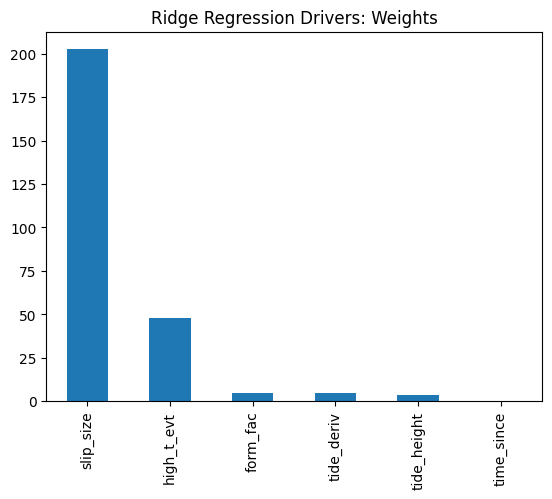

In [23]:

#Plot of drivers with weights

plt.figure()
drivers.abs().plot.bar()
plt.title("Ridge Regression Drivers: Weights")
plt.show()


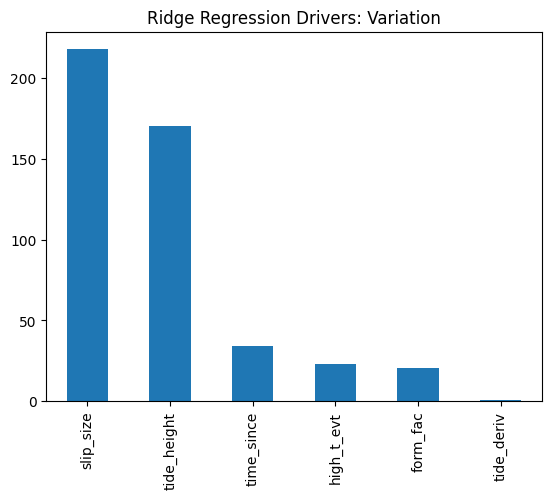

In [24]:
#Plot of drivers with varience:
plt.figure()
drivers_vari.abs().plot.bar()
plt.title("Ridge Regression Drivers: Variation")
plt.show()

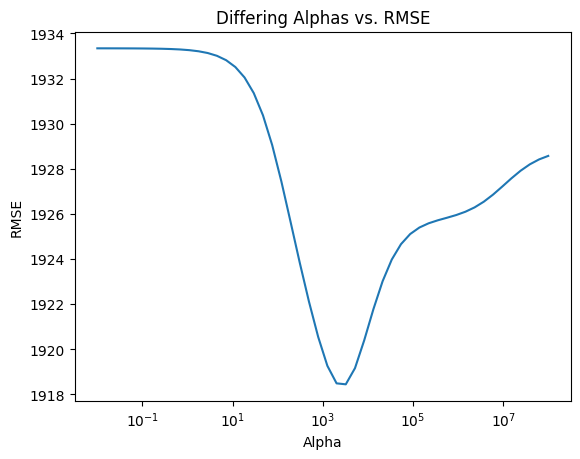

In [25]:
# Alpha values vs MAE
plt.figure()
plt.plot(alphas, val_RMSE)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('RMSE')
plt.title('Differing Alphas vs. RMSE')
plt.show()

#Multiplicative Error vs Actual Value for Ridge Regression

#Error in terms of seconds for Ridge Regression (may need to unscale and then recompute a MAE for this one)


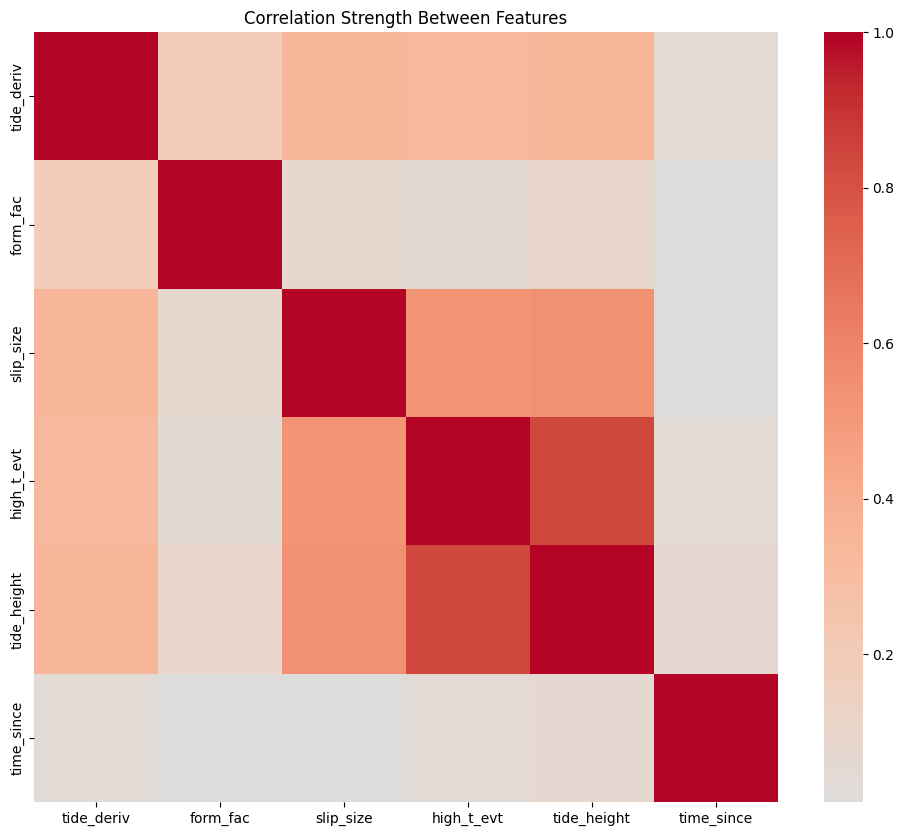

Condition Number: 40736.74726975986


In [26]:
# What about the data set drove getting that optimal alpha value:
correlation = X_train.corr().abs() #Seeing correlation of the features
plt.figure(figsize=(12,10)) #Visualizing the feature correlation
sns.heatmap(correlation, cmap='coolwarm', center=0)
plt.title('Correlation Strength Between Features')
plt.show()
#print("Feature correlation:", correlation)

#Statistical measure of whether there are likely redundant features (checking linear independence)
condition = np.linalg.cond(X_train)
print("Condition Number:", condition)

Sample0: True = 665.00s, Predicted = 1028.31s, Error=363.31s
Sample1: True = 897.75s, Predicted = 1076.61s, Error=178.86s
Sample2: True = 1377.25s, Predicted = 1311.38s, Error=65.87s
Sample3: True = 1545.00s, Predicted = 1037.38s, Error=507.62s
Sample4: True = 1230.00s, Predicted = 887.64s, Error=342.36s
Sample5: True = 803.75s, Predicted = 932.10s, Error=128.35s
Sample6: True = 790.00s, Predicted = 1089.42s, Error=299.42s
Sample7: True = 1196.25s, Predicted = 1124.48s, Error=71.77s
Sample8: True = 920.00s, Predicted = 1081.99s, Error=161.99s
Sample9: True = 715.00s, Predicted = 1150.45s, Error=435.45s
Sample10: True = 1223.75s, Predicted = 1213.14s, Error=10.61s
Sample11: True = 1396.25s, Predicted = 1215.84s, Error=180.41s
Sample12: True = 1448.75s, Predicted = 1074.83s, Error=373.92s
Sample13: True = 1446.25s, Predicted = 1141.67s, Error=304.58s
Sample14: True = 1505.00s, Predicted = 1243.36s, Error=261.64s
Sample15: True = 615.00s, Predicted = 1044.12s, Error=429.12s
Sample16: True

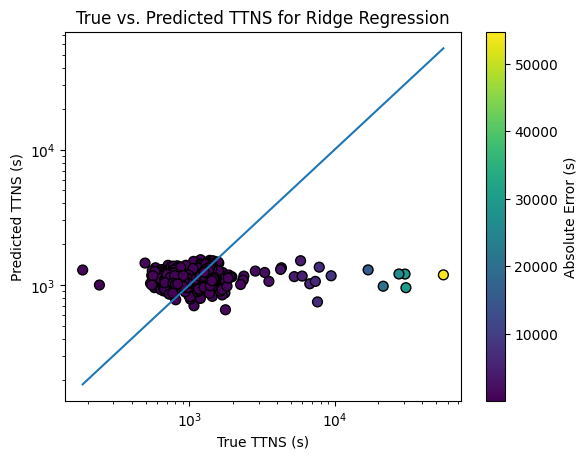

In [27]:
# Ridge Prediction Analysis:

y_test_secs = y_test #Taking it out of log scale
y_pred_secs = y_final_prediction

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Ridge Regression")
plt.xscale('log')
plt.yscale('log')
plt.show()